In [12]:
import torch
import numpy as np
import json
import sys
import os
from flappy_env import FlappyEnv
from dqn_model import DQN

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch

%matplotlib inline

In [2]:
MODEL_PATH = "./models/flappy_dqn_2800.pth"
NUM_EPISODES = 100
OUTPUT_FILE = "eval_results.json"

In [3]:
def count_pipes(env_log):
    """Đếm số ống vượt qua dựa vào pipe_x transitions."""
    return env_log

In [4]:
def evaluate(model_path, num_episodes):
    env = FlappyEnv()
    model = DQN(8, 256, 2)
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval()
 
    results = []
 
    for ep in range(num_episodes):
        state = env.reset()
        total_reward = 0.0
        steps = 0
        pipes_passed = 0
        actions = []
        prev_pipe_x = env.pipe_x
 
        while True:
            with torch.no_grad():
                action = model(torch.tensor(state).float()).argmax().item()
 
            actions.append(action)
            next_state, reward, done = env.step(action)
 
            # Đếm ống vượt qua: pipe_x vừa reset về 450 sau khi ra khỏi màn hình
            if env.pipe_x > prev_pipe_x:
                pipes_passed += 1
            prev_pipe_x = env.pipe_x
 
            total_reward += reward
            steps += 1
            state = next_state
 
            if done:
                break
 
        jump_count = sum(actions)
        jump_rate = jump_count / steps if steps > 0 else 0
 
        results.append({
            "episode": ep,
            "total_reward": round(total_reward, 2),
            "steps": steps,
            "pipes_passed": pipes_passed,
            "jump_count": jump_count,
            "jump_rate": round(jump_rate, 4),
        })
 
        print(f"[{ep+1:>3}/{num_episodes}] reward={total_reward:>8.1f} | "
              f"steps={steps:>5} | pipes={pipes_passed} | jump_rate={jump_rate:.2%}")
 
    # Thống kê tổng hợp
    rewards = [r["total_reward"] for r in results]
    pipes   = [r["pipes_passed"] for r in results]
    steps_l = [r["steps"] for r in results]
    jrates  = [r["jump_rate"] for r in results]
 
    summary = {
        "num_episodes": num_episodes,
        "model_path": model_path,
        "reward": {
            "mean": round(float(np.mean(rewards)), 2),
            "std":  round(float(np.std(rewards)),  2),
            "min":  round(float(np.min(rewards)),  2),
            "max":  round(float(np.max(rewards)),  2),
        },
        "pipes_passed": {
            "mean": round(float(np.mean(pipes)), 2),
            "std":  round(float(np.std(pipes)),  2),
            "min":  int(np.min(pipes)),
            "max":  int(np.max(pipes)),
        },
        "steps": {
            "mean": round(float(np.mean(steps_l)), 2),
            "max":  int(np.max(steps_l)),
        },
        "jump_rate": {
            "mean": round(float(np.mean(jrates)), 4),
            "std":  round(float(np.std(jrates)),  4),
        },
    }
 
    output = {"summary": summary, "episodes": results}
 
    with open(OUTPUT_FILE, "w") as f:
        json.dump(output, f, indent=2)
 
    print("\n" + "="*55)
    print(f"  KẾT QUẢ ĐÁNH GIÁ ({num_episodes} episodes)")
    print("="*55)
    print(f"  Reward   : {summary['reward']['mean']} ± {summary['reward']['std']}")
    print(f"             min={summary['reward']['min']}  max={summary['reward']['max']}")
    print(f"  Pipes    : {summary['pipes_passed']['mean']} ± {summary['pipes_passed']['std']}")
    print(f"             min={summary['pipes_passed']['min']}  max={summary['pipes_passed']['max']}")
    print(f"  Steps    : avg={summary['steps']['mean']}  max={summary['steps']['max']}")
    print(f"  Jump rate: {summary['jump_rate']['mean']:.2%} ± {summary['jump_rate']['std']:.2%}")
    print("="*55)
    print(f"\n  Kết quả đã lưu vào: {OUTPUT_FILE}")

In [5]:
evaluate(MODEL_PATH, NUM_EPISODES)

[  1/100] reward=   -11.3 | steps=  285 | pipes=1 | jump_rate=9.12%
[  2/100] reward=   122.8 | steps= 1120 | pipes=6 | jump_rate=8.39%
[  3/100] reward=   -38.2 | steps=  117 | pipes=0 | jump_rate=17.09%
[  4/100] reward=   578.7 | steps= 3959 | pipes=23 | jump_rate=7.40%
[  5/100] reward=   257.4 | steps= 1955 | pipes=11 | jump_rate=10.03%
[  6/100] reward=    69.2 | steps=  786 | pipes=4 | jump_rate=9.16%
[  7/100] reward=   605.8 | steps= 4126 | pipes=24 | jump_rate=7.97%
[  8/100] reward=   -38.2 | steps=  117 | pipes=0 | jump_rate=16.24%
[  9/100] reward=   151.0 | steps= 1301 | pipes=7 | jump_rate=7.38%
[ 10/100] reward=   230.3 | steps= 1788 | pipes=10 | jump_rate=8.72%
[ 11/100] reward=   -38.2 | steps=  117 | pipes=0 | jump_rate=16.24%
[ 12/100] reward=   579.5 | steps= 3959 | pipes=23 | jump_rate=9.27%
[ 13/100] reward=   -38.2 | steps=  117 | pipes=0 | jump_rate=16.24%
[ 14/100] reward=   632.6 | steps= 4293 | pipes=25 | jump_rate=8.01%
[ 15/100] reward=  2805.2 | steps=178

In [ ]:
with open(OUTPUT_FILE) as f:
    data = json.load(f)

summary  = data["summary"]
episodes = data["episodes"]

eps    = [e["episode"]     for e in episodes]
rewards= [e["total_reward"]for e in episodes]
pipes  = [e["pipes_passed"]for e in episodes]
steps  = [e["steps"]       for e in episodes]
jrates = [e["jump_rate"]   for e in episodes]

print(f"Loaded {len(episodes)} episodes from '{OUTPUT_FILE}'")
print(f"Avg reward: {summary['reward']['mean']} | Avg pipes: {summary['pipes_passed']['mean']}")

Loaded 100 episodes from 'eval_results.json'
Avg reward: 395.76 | Avg pipes: 16.17


In [15]:
def rolling(arr, w=10):
    result = []
    for i in range(len(arr)):
        start = max(0, i - w + 1)
        result.append(np.mean(arr[start:i+1]))
    return result

BG      = "#0f1117"
PANEL   = "#1a1d27"
ACCENT  = "#00e5ff"
ACCENT2 = "#ff4081"
ACCENT3 = "#69ff47"
ACCENT4 = "#ffd740"
TEXT    = "#e0e0e0"
SUBTEXT = "#888"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   PANEL,
    "axes.edgecolor":   "#2a2d3a",
    "axes.labelcolor":  TEXT,
    "xtick.color":      SUBTEXT,
    "ytick.color":      SUBTEXT,
    "text.color":       TEXT,
    "grid.color":       "#2a2d3a",
    "grid.linestyle":   "--",
    "grid.alpha":       0.6,
    "font.family":      "monospace",
})

def stat_box(ax, label, value, sub, color):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis("off")
    rect = FancyBboxPatch((0.05, 0.1), 0.9, 0.8,
                          boxstyle="round,pad=0.05",
                          facecolor=PANEL, edgecolor=color,
                          linewidth=2, zorder=0)
    ax.add_patch(rect)
    ax.text(0.5, 0.72, label, ha="center", va="center", fontsize=10, color=SUBTEXT)
    ax.text(0.5, 0.45, value, ha="center", va="center", fontsize=22,
            fontweight="bold", color=color)
    ax.text(0.5, 0.18, sub,   ha="center", va="center", fontsize=9,  color=SUBTEXT)

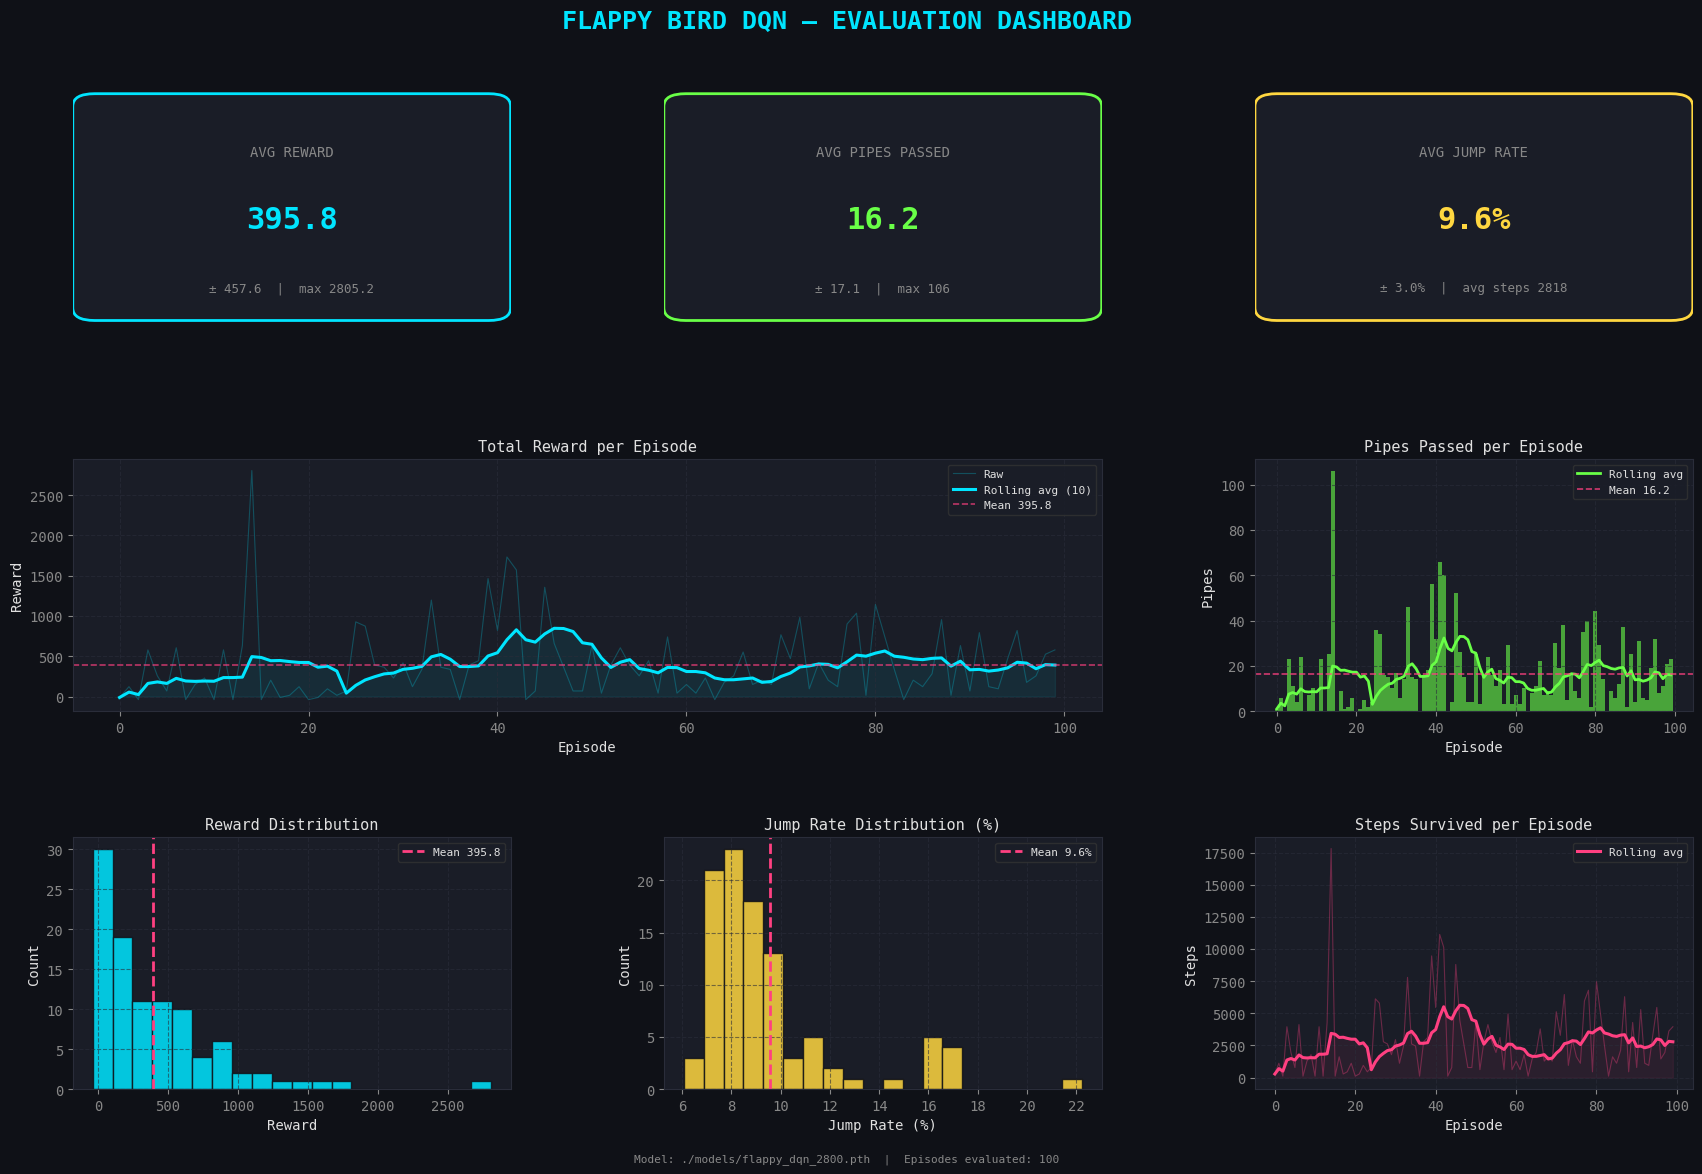

In [ ]:
fig = plt.figure(figsize=(18, 12), facecolor=BG)
fig.suptitle("FLAPPY BIRD DQN — EVALUATION DASHBOARD",
             fontsize=18, fontweight="bold", color=ACCENT,
             y=0.97, fontfamily="monospace")

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35,
                       top=0.91, bottom=0.07, left=0.07, right=0.97)

stat_box(fig.add_subplot(gs[0, 0]),
         "AVG REWARD",
         f"{summary['reward']['mean']:.1f}",
         f"± {summary['reward']['std']:.1f}  |  max {summary['reward']['max']:.1f}",
         ACCENT)

stat_box(fig.add_subplot(gs[0, 1]),
         "AVG PIPES PASSED",
         f"{summary['pipes_passed']['mean']:.1f}",
         f"± {summary['pipes_passed']['std']:.1f}  |  max {summary['pipes_passed']['max']}",
         ACCENT3)

stat_box(fig.add_subplot(gs[0, 2]),
         "AVG JUMP RATE",
         f"{summary['jump_rate']['mean']:.1%}",
         f"± {summary['jump_rate']['std']:.1%}  |  avg steps {summary['steps']['mean']:.0f}",
         ACCENT4)

ax1 = fig.add_subplot(gs[1, :2])
ax1.plot(eps, rewards, color=ACCENT, alpha=0.25, linewidth=0.8, label="Raw")
ax1.plot(eps, rolling(rewards), color=ACCENT, linewidth=2.2, label="Rolling avg (10)")
ax1.axhline(summary["reward"]["mean"], color=ACCENT2, linestyle="--",
            linewidth=1.2, alpha=0.7, label=f"Mean {summary['reward']['mean']:.1f}")
ax1.fill_between(eps, rolling(rewards), alpha=0.08, color=ACCENT)
ax1.set_title("Total Reward per Episode", color=TEXT, fontsize=11)
ax1.set_xlabel("Episode"); ax1.set_ylabel("Reward")
ax1.legend(fontsize=8, facecolor=PANEL, edgecolor="#333")
ax1.grid(True)

ax2 = fig.add_subplot(gs[1, 2])
ax2.bar(eps, pipes, color=ACCENT3, alpha=0.6, width=1.0)
ax2.plot(eps, rolling(pipes), color=ACCENT3, linewidth=2, label="Rolling avg")
ax2.axhline(summary["pipes_passed"]["mean"], color=ACCENT2, linestyle="--",
            linewidth=1.2, alpha=0.8, label=f"Mean {summary['pipes_passed']['mean']:.1f}")
ax2.set_title("Pipes Passed per Episode", color=TEXT, fontsize=11)
ax2.set_xlabel("Episode"); ax2.set_ylabel("Pipes")
ax2.legend(fontsize=8, facecolor=PANEL, edgecolor="#333")
ax2.grid(True)

ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(rewards, bins=20, color=ACCENT, edgecolor=BG, alpha=0.85)
ax3.axvline(summary["reward"]["mean"], color=ACCENT2, linewidth=2,
            linestyle="--", label=f"Mean {summary['reward']['mean']:.1f}")
ax3.set_title("Reward Distribution", color=TEXT, fontsize=11)
ax3.set_xlabel("Reward"); ax3.set_ylabel("Count")
ax3.legend(fontsize=8, facecolor=PANEL, edgecolor="#333")
ax3.grid(True)

ax4 = fig.add_subplot(gs[2, 1])
ax4.hist([r * 100 for r in jrates], bins=20, color=ACCENT4, edgecolor=BG, alpha=0.85)
ax4.axvline(summary["jump_rate"]["mean"] * 100, color=ACCENT2, linewidth=2,
            linestyle="--", label=f"Mean {summary['jump_rate']['mean']:.1%}")
ax4.set_title("Jump Rate Distribution (%)", color=TEXT, fontsize=11)
ax4.set_xlabel("Jump Rate (%)"); ax4.set_ylabel("Count")
ax4.legend(fontsize=8, facecolor=PANEL, edgecolor="#333")
ax4.grid(True)

ax5 = fig.add_subplot(gs[2, 2])
ax5.plot(eps, steps, color=ACCENT2, alpha=0.35, linewidth=0.8)
ax5.plot(eps, rolling(steps), color=ACCENT2, linewidth=2.2, label="Rolling avg")
ax5.fill_between(eps, rolling(steps), alpha=0.07, color=ACCENT2)
ax5.set_title("Steps Survived per Episode", color=TEXT, fontsize=11)
ax5.set_xlabel("Episode"); ax5.set_ylabel("Steps")
ax5.legend(fontsize=8, facecolor=PANEL, edgecolor="#333")
ax5.grid(True)

fig.text(0.5, 0.01,
         f"Model: {summary['model_path']}  |  Episodes evaluated: {summary['num_episodes']}",
         ha="center", fontsize=8, color=SUBTEXT)

plt.show()